# Exercise 2 - NLP basics
_By Georg Ahnert. Based on content by Abigail Hayes and Indira Sen._

This exercise concerns NLP basics and explores a range of methods which pre-date LLMs. We will cover the following:
- Tokenisation
- Bag-of-words and n-gram vectorization
- Classification

There will then be the opportunity to try further variants yourself.

## Setup

First we will set up our environment and prepare a dataset.

### Creating a virtual environment

If you run this notebook for the first time on the **BWUniCluster3.0**, you'll have to do some initial setup.

First, make sure that you have started a `minimal` jupyter instance as **starting an `ai` instance will likely lead to package conflicts!** Once the instance is started, open a new **Terminal** tab. Then, create a virtual environment (similar to a conda environment) and activate the environment like this:

```bash
python -m venv llm4ess_env
source llm4ess_env/bin/activate
```

Next, we need to install the minimum requirements for using our new environment as a kernel for Jupyter Notebooks. And finally, we can create a kernel based on this environment:

```bash
pip install ipykernel ipywidgets
python -m ipykernel install --user --name llm4ess --display-name "Python (LLM4ESS)" 
```

Now you can close the terminal and reload the browser window. The new kernel named `Python (LLM4ESS)` should now show up in the drop-down menu on the top right of your jupyter notebook.

You can list existing kernels with ``jupyter kernelspec list``

And remove kernels with ``jupyter kernelspec remove old_kernel``

To remve the virtual environment, simply delete the folder.

### Installing dependencies

If these Python packages are not yet available in your environment, then you should install them.
- numpy - for working with data
- pandas - for data analysis
- matplotlib - for plotting
- nltk - for natural language processing
- sklearn - install as scikit-learn - for machine learning

In [1]:
%pip install numpy pandas matplotlib nltk scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import matplotlib

### Download data

Now we will load the dataset that we are working with today. The TweetSemEval dataset contains a set of tweets and the aim is to identify if the sentiment of each tweet is positive, negative or neutral. The correct labels are already provided.

The data comes from a shared task, where researchers competed to produce the best performing models. You can also look at the [final report](https://aclanthology.org/S17-2088/) and the [GitHub repository](https://github.com/leelaylay/TweetSemEval).


In [3]:
datapath = 'https://raw.githubusercontent.com/leelaylay/TweetSemEval/master/dataset/train/twitter-2013train-A.txt'
data = pd.read_csv(datapath, sep = '\t', names = ['id', 'sentiment', 'text'])
data

,id,sentiment,text
0,264183816548130816,positive,Gas by my house hit $3.39!!!! I\u2019m going t...
1,263405084770172928,negative,Theo Walcott is still shit\u002c watch Rafa an...
2,262163168678248449,negative,its not that I\u2019m a GSP fan\u002c i just h...
3,264249301910310912,negative,Iranian general says Israel\u2019s Iron Dome c...
4,262682041215234048,neutral,Tehran\u002c Mon Amour: Obama Tried to Establi...
...,...,...,...
9679,103158179306807296,positive,RT @MNFootNg It's monday and Monday Night Foot...
9680,103157324096618497,positive,All I know is the road for that Lomardi start ...
9681,100259220338905089,neutral,"All Blue and White fam, we r meeting at Golden..."
9682,104230318525001729,positive,@DariusButler28 Have a great game agaist Tam...


We can already see that there are 9,684 rows where each represents a tweet. For each tweet, we have an id number, the sentiment classification and the text from the tweet.

## Data exploration and preparation

We can now explore further by looking at how many tweets belong to each category:

<Axes: xlabel='sentiment'>

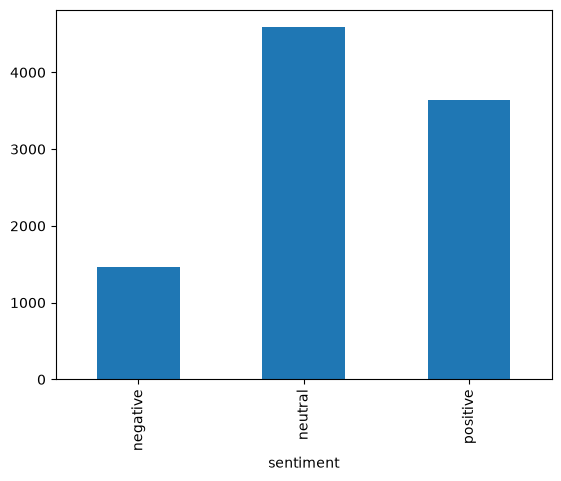

In [4]:
data.groupby('sentiment').size().plot(kind = 'bar')

In [5]:
print('Full data length:', data.shape[0])

print('Unique tweets:', data['text'].nunique())

Full data length: 9684
Unique tweets: 9649


### Tokens

The text must now be broken down into tokens. Each tokenizer has different rules for some more unusual cases, but roughly equates to separating out individual words. More modern tokenizers also split subwords (e.g., "toke"-"niz"-"er"), but we'll use a basic tokenizer for now. We will use a tweet specific tokenizer so that it can handle the specific tokens that are specific to social media.

In [6]:
from nltk.tokenize import TweetTokenizer

tt = TweetTokenizer()
# Example text
tweet = "This is a cooool #dummysmiley: :-) :-P <3 and some arrows < > -> <-- @remy: This is waaaaayyyy too much for you!!!!!!"
print(tt.tokenize(tweet))

['This', 'is', 'a', 'cooool', '#dummysmiley', ':', ':-)', ':-P', '<3', 'and', 'some', 'arrows', '<', '>', '->', '<--', '@remy', ':', 'This', 'is', 'waaaaayyyy', 'too', 'much', 'for', 'you', '!', '!', '!']


In [7]:
tweet = data['text'][4]
print(tt.tokenize(tweet))

['Tehran', '\\', 'u002c', 'Mon', 'Amour', ':', 'Obama', 'Tried', 'to', 'Establish', 'Ties', 'with', 'the', 'Mullahs', 'http://t.co/TZZzrrKa', 'via', '@PJMedia_com', 'No', 'Barack', 'Obama', '-', 'Vote', 'Mitt', 'Romney']


From these tokens, we can now extract certain information about each tweet e.g. the number of urls.

In [8]:
def url_count(row):
    count = 0
    tokens = tt.tokenize(row['text'])
    for token in tokens:
        if token.startswith('http'):
            count += 1
    return count

In [9]:
url_count(data.iloc[4])

1

In [10]:
data['url_count'] = data.apply(url_count, axis = 1)
data.head(5)

,id,sentiment,text,url_count
0,264183816548130816,positive,Gas by my house hit $3.39!!!! I\u2019m going t...,0
1,263405084770172928,negative,Theo Walcott is still shit\u002c watch Rafa an...,0
2,262163168678248449,negative,its not that I\u2019m a GSP fan\u002c i just h...,0
3,264249301910310912,negative,Iranian general says Israel\u2019s Iron Dome c...,0
4,262682041215234048,neutral,Tehran\u002c Mon Amour: Obama Tried to Establi...,1


<Axes: xlabel='url_count'>

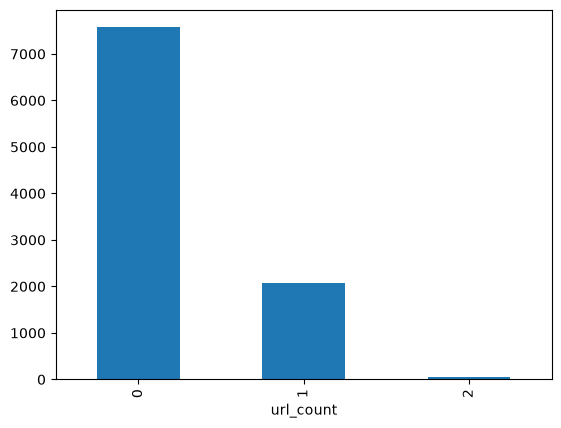

In [11]:
data.groupby('url_count').size().plot(kind = 'bar')

### Train-test split

Our end goal is to build a classifier and see how well it can classify the sentiment of different tweets. As a result, we want to use some data to train the classifier and also keep some data for testing. Sklearn helps us to do this.

The `X` value is the data that will be the input to our classifier model—here the text of the tweet. The `y` value is what the model should predict—here the sentiment of the tweet.

In [12]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(data, test_size = 0.3)

In [13]:
X_train = train['text'].values
y_train = train['sentiment'].values
X_test = test['text'].values
y_test = test['sentiment'].values

## Bag-of-words and n-grams

We cannot just provide the text data as it is. Instead we need to convert them to a vector representation i.e. a series of numerical values. You have seen various options for doing this in the lectures.

### Bag-of-words

Bag-of-words counts how often each word appears in a text. This ignores both the order and the meaning. The assumption would be that similar documents have similar counts of each word. This can also be referred to as unigrams.

**fit**: Learn a vocabulary dictionary of all tokens in the raw documents.

**transform**: Transform documents to document-term matrix.

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer() # initialize the vectorizer

In [15]:
# create the representation
vectorizer.fit(X_train)

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"stop_words stop_words: {'english'}, list, default=NoneIf 'english', a built-in stop word list for English is used.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str or None, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp select tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentword n-grams or char n-grams to be extracted. All values of n suchsuch that min_n <= n <= max_n will be used. For example an``ngram_range`` of ``(1, 1)`` means only unigrams, ``(1, 2)`` meansunigrams and bigrams, and ``(2, 2)`` means only bigrams.Only applies if ``analyzer`` is not callable.","(1, ...)"
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word n-gram or charactern-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21Since v0.21, if ``input`` is ``filename`` or ``file``, the data isfirst read from the file and then passed to the given callableanalyzer.",'word'


In [16]:
len(vectorizer.vocabulary_)

18880

In [17]:
bag_of_words = vectorizer.transform(X_train)
print('Bag-of-words dimensions:')
print(bag_of_words.shape)
print('Bag-of-words matrix:')
print(bag_of_words.toarray())

Bag-of-words dimensions:
(6778, 18880)
Bag-of-words matrix:
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


#### Bigrams

Rather than just looking at single words, now we will consider pairs of words. This means that some of the word order is being incorporated.

In [18]:
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))
bigram_vectorizer.fit(X_train)
bigram_vectorizer.get_feature_names_out()

array(['00 50', '00 argentina', '00 at', ..., 'zumba tonight',
       'zurr08 will', 'zz gud'], shape=(77075,), dtype=object)

In [19]:
bigrams = bigram_vectorizer.transform(X_train).toarray()
bigrams.shape

(6778, 77075)

#### Unigrams and bigrams

We can also use both unigrams and bigrams together, increasing the number of possible combinations still further.

In [20]:
unibigram_vectorizer = CountVectorizer(ngram_range=(1, 2))
unibigram_vectorizer.fit(X_train)
uni_bigrams = unibigram_vectorizer.transform(X_train).toarray()
uni_bigrams.shape

(6778, 95955)

## Classification

Now we will build classifiers with these different vector representations. We can then compare the classifier model predictions for the test data to the correct values.

There are lots of possible models to use for classification, we will use logistic regression.

We start with the bag-of-words approach and train the model.

In [21]:
from sklearn.linear_model import LogisticRegression
lg = LogisticRegression(random_state=0)
clf = lg.fit(bag_of_words.toarray(), y_train)

Now to make predictions on the test data.

In [22]:
X_test_v = vectorizer.transform(X_test)
y_pred = clf.predict(X_test_v.toarray())

### Evaluation

First look at a few results.

In [23]:
pd.DataFrame([X_test[:5], y_pred[:5], y_test[:5]]).T

,0,1,2
0,Red Band End Of Watch Trailer Arrives: Gyllenh...,neutral,neutral
1,#catherinebelll I watched good witch for the 1...,positive,positive
2,So far today Ive been asked who will win the R...,neutral,neutral
3,I\u2019m going as Scott Peterson tomorrow and ...,negative,neutral
4,SS4 - 1 Mikko 10.45\u002c9 - 2 Petter +0\u002c...,neutral,neutral


In [24]:
anti_tweet = "Ugh, this was true yesterday and it's also true now: Tom is an idiot"
clf.predict(vectorizer.transform([anti_tweet]))

array(['negative'], dtype=object)

Sklearn has various functions for examining results.

In [25]:
from sklearn.metrics import classification_report # good for computing these metrics

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.54      0.38      0.45       424
     neutral       0.66      0.77      0.71      1367
    positive       0.69      0.64      0.66      1115

    accuracy                           0.66      2906
   macro avg       0.63      0.59      0.61      2906
weighted avg       0.66      0.66      0.65      2906



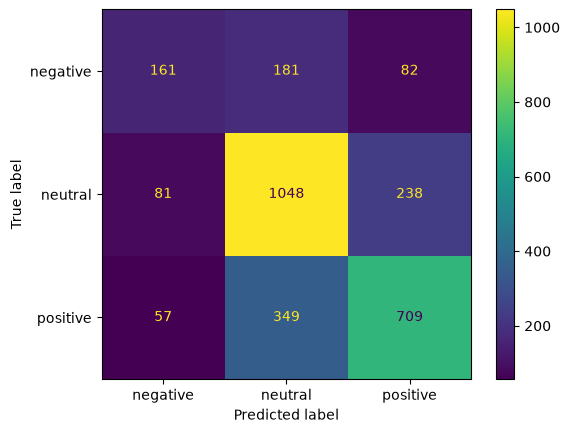

In [26]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot()

We will store these predictions for later.

In [27]:
results = {}
results['bow_sentiment'] = y_pred

### Compare methods

We can now repeat the process with the unigram and bigram combined vectorizer comparing the results.

In [28]:
lg = LogisticRegression(random_state=0)
clf = lg.fit(uni_bigrams, y_train)
X_test_v = unibigram_vectorizer.transform(X_test)
y_pred = clf.predict(X_test_v.toarray())
results['unibigram_sentiment'] = y_pred

In [29]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.56      0.34      0.43       424
     neutral       0.66      0.80      0.72      1367
    positive       0.71      0.62      0.66      1115

    accuracy                           0.67      2906
   macro avg       0.64      0.59      0.60      2906
weighted avg       0.66      0.67      0.66      2906



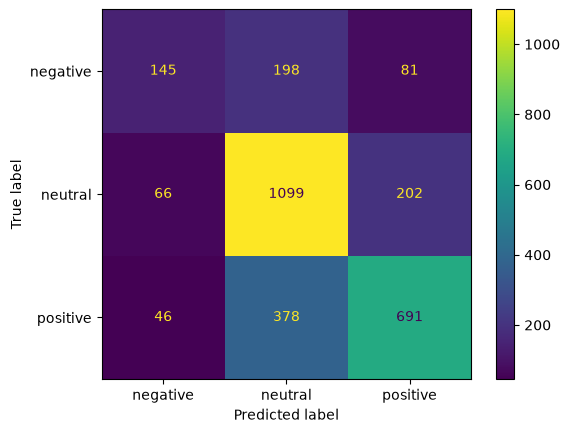

In [30]:
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf.classes_).plot()

## Task 1

Whether only using unigrams or also incorporating bigrams, these models have similar performance. Try the same approach with TF-IDF and see if this is better able to classify.

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(X_train)
X_train_tfidf = tfidf_vectorizer.transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

lg = LogisticRegression(random_state=0)
clf_tfidf = lg.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

results['tfidf_sentiment'] = y_pred_tfidf
print("TF-IDF (unigrams):")
print(classification_report(y_test, y_pred_tfidf))

TF-IDF (unigrams):
              precision    recall  f1-score   support

    negative       0.57      0.25      0.34       424
     neutral       0.64      0.82      0.72      1367
    positive       0.70      0.62      0.66      1115

    accuracy                           0.66      2906
   macro avg       0.64      0.56      0.57      2906
weighted avg       0.66      0.66      0.64      2906



TF-IDF (unigrams + bigrams):
              precision    recall  f1-score   support

    negative       0.59      0.19      0.29       424
     neutral       0.63      0.81      0.71      1367
    positive       0.68      0.62      0.65      1115

    accuracy                           0.65      2906
   macro avg       0.63      0.54      0.55      2906
weighted avg       0.64      0.65      0.63      2906



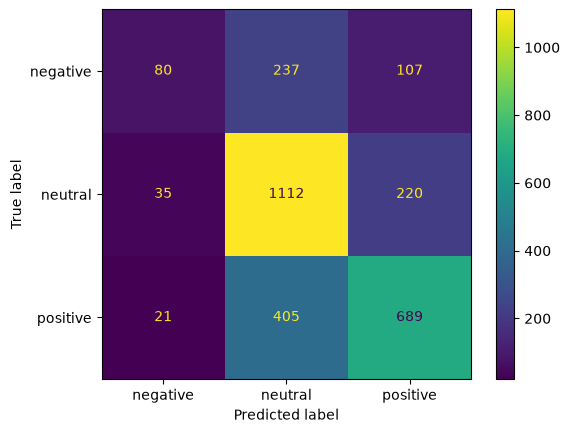

In [ ]:
# unigrams and bigrams with tf-idf
tfidf_unibigram_vectorizer = TfidfVectorizer(ngram_range=(1, 2))
tfidf_unibigram_vectorizer.fit(X_train)
X_train_tfidf_ub = tfidf_unibigram_vectorizer.transform(X_train)
X_test_tfidf_ub = tfidf_unibigram_vectorizer.transform(X_test)

lg = LogisticRegression(random_state=0)
clf_tfidf_ub = lg.fit(X_train_tfidf_ub, y_train)
y_pred_tfidf_ub = clf_tfidf_ub.predict(X_test_tfidf_ub)

results['tfidf_unibigram_sentiment'] = y_pred_tfidf_ub
print("TF-IDF (unigrams + bigrams):")
print(classification_report(y_test, y_pred_tfidf_ub))

cm = confusion_matrix(y_test, y_pred_tfidf_ub)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_tfidf_ub.classes_).plot()

## Task 2

Thus far we have vectorized the text data without pre-processing. Try creating a version of the data where all the tweets have any mentions (@) and urls removed. Use this data for a combined unigrams and bigrams representation to train a logistic regression model.

 _Hint: adapt the function that we used earlier to find urls_

In [39]:
def clean_tweet(row):
    tokens = tt.tokenize(row['text'])
    cleaned = [t for t in tokens if not t.startswith('@') and not t.startswith('http')]
    return ' '.join(cleaned)

data['text_clean'] = data.apply(clean_tweet, axis=1)
data[['text', 'text_clean']].head()

,text,text_clean
0,Gas by my house hit $3.39!!!! I\u2019m going t...,Gas by my house hit $ 3.39 ! ! ! I \ u2019m go...
1,Theo Walcott is still shit\u002c watch Rafa an...,Theo Walcott is still shit \ u002c watch Rafa ...
2,its not that I\u2019m a GSP fan\u002c i just h...,its not that I \ u2019m a GSP fan \ u002c i ju...
3,Iranian general says Israel\u2019s Iron Dome c...,Iranian general says Israel \ u2019s Iron Dome...
4,Tehran\u002c Mon Amour: Obama Tried to Establi...,Tehran \ u002c Mon Amour : Obama Tried to Esta...


In [34]:
# Re-split using the cleaned text
train_clean, test_clean = train_test_split(data, test_size=0.3, random_state=42)
X_train_clean = train_clean['text_clean'].values
y_train_clean = train_clean['sentiment'].values
X_test_clean = test_clean['text_clean'].values
y_test_clean = test_clean['sentiment'].values

In [35]:
clean_vectorizer = CountVectorizer(ngram_range=(1, 2))
clean_vectorizer.fit(X_train_clean)
X_train_clean_v = clean_vectorizer.transform(X_train_clean)
X_test_clean_v = clean_vectorizer.transform(X_test_clean)

lg = LogisticRegression(random_state=0)
clf_clean = lg.fit(X_train_clean_v, y_train_clean)
y_pred_clean = clf_clean.predict(X_test_clean_v)

results['clean_unibigram_sentiment'] = y_pred_clean
print("Cleaned text (unigrams + bigrams):")
print(classification_report(y_test_clean, y_pred_clean))

Cleaned text (unigrams + bigrams):
              precision    recall  f1-score   support

    negative       0.59      0.33      0.42       443
     neutral       0.67      0.79      0.73      1389
    positive       0.69      0.65      0.67      1074

    accuracy                           0.67      2906
   macro avg       0.65      0.59      0.60      2906
weighted avg       0.66      0.67      0.66      2906



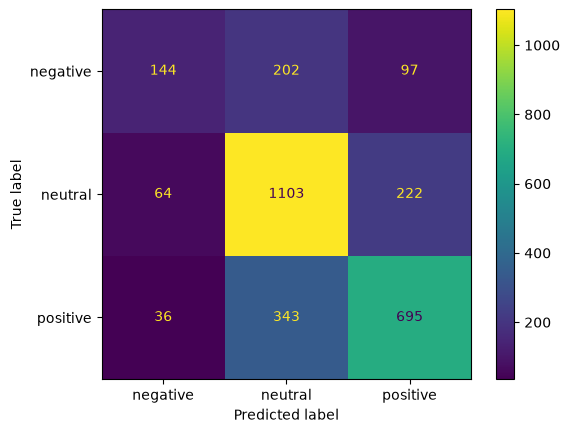

In [36]:
cm = confusion_matrix(y_test_clean, y_pred_clean)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=clf_clean.classes_).plot()

## Word embeddings

Packages for word embeddings are no longer as well maintained. We have a [Google Colab Jupyter Notebook](https://colab.research.google.com/drive/1saTSEzYYTrgI_gzlcTmm0zjkD-7L3opL?usp=sharing) where you can try one out. You can create your own copy and will need to install gensim in Colab first.